In [22]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

# Chart style
plt.rcParams['figure.figsize']  = (14, 6)
plt.rcParams['font.size']       = 12
plt.rcParams['axes.titlesize']  = 14
plt.rcParams['axes.titleweight']= 'bold'
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Create folder to save charts
CHARTS_FOLDER = r"C:\Users\Admin\Desktop\Codezela\Data Analyst session - Final Project\charts"
os.makedirs(CHARTS_FOLDER, exist_ok=True)
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
#LOAD THE DATASET
FILE_PATH = r"C:\Users\Admin\Desktop\Codezela\Data Analyst session - Final Project\Online Retail.csv"

print("Loading dataset...")

df_raw = pd.read_csv(
    FILE_PATH,
    encoding='latin-1',       # This file requires latin-1 encoding
    dtype={                   # Load these as strings to avoid issues
        'InvoiceNo'  : str,
        'StockCode'  : str,
        'Description': str,
        'CustomerID' : str,
        'Country'    : str,
    }
)

print(f"✅ Dataset loaded successfully!")
print(f"   Rows    : {df_raw.shape[0]:,}")
print(f"   Columns : {df_raw.shape[1]}")
print(f"\nColumn Names: {list(df_raw.columns)}")


Loading dataset...
✅ Dataset loaded successfully!
   Rows    : 541,909
   Columns : 8

Column Names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [3]:
#DATASET OVERVIEW
print("=" * 60)
print("DATASET OVERVIEW — First 5 Rows")
print("=" * 60)
display(df_raw.head())

print("\n" + "=" * 60)
print("COLUMN DATA TYPES")
print("=" * 60)
print(df_raw.dtypes)

print("\n" + "=" * 60)
print("BASIC STATISTICS (Numeric Columns)")
print("=" * 60)
display(df_raw[['Quantity', 'UnitPrice']].describe())

print("\n" + "=" * 60)
print("UNIQUE VALUES PER COLUMN")
print("=" * 60)
for col in df_raw.columns:
    print(f"  {col:<15}: {df_raw[col].nunique():>6,} unique values")


DATASET OVERVIEW — First 5 Rows


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850,United Kingdom



COLUMN DATA TYPES
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID      object
Country         object
dtype: object

BASIC STATISTICS (Numeric Columns)


,Quantity,UnitPrice
count,"541,909.00","541,909.00"
mean,9.55,4.61
std,218.08,96.76
min,"-80,995.00","-11,062.06"
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,"80,995.00","38,970.00"



UNIQUE VALUES PER COLUMN
  InvoiceNo      : 25,900 unique values
  StockCode      :  4,070 unique values
  Description    :  4,223 unique values
  Quantity       :    722 unique values
  InvoiceDate    : 23,260 unique values
  UnitPrice      :  1,630 unique values
  CustomerID     :  4,372 unique values
  Country        :     38 unique values


MISSING VALUE ANALYSIS


,Missing Count,Missing %
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


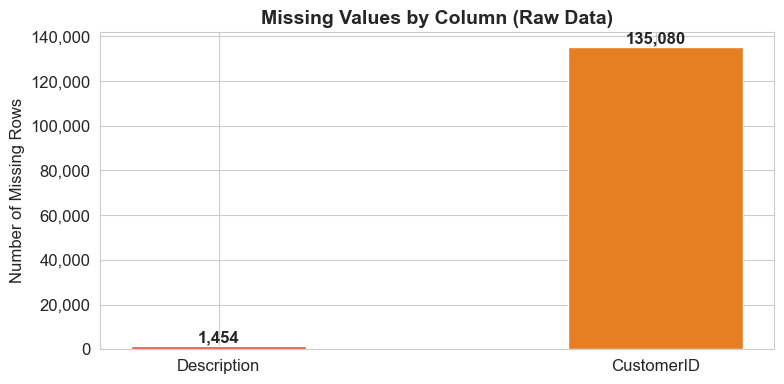

✅ Chart saved: 01_missing_values.png


In [4]:
# MISSING VALUE ANALYSIS
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing_count = df_raw.isnull().sum()
missing_pct   = (missing_count / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %'    : missing_pct
}).sort_values('Missing Count', ascending=False)

display(missing_df)

# Chart — Missing Values
cols_with_missing = missing_count[missing_count > 0]
if len(cols_with_missing) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(cols_with_missing.index, cols_with_missing.values,
                  color=['#e74c3c', '#e67e22'], edgecolor='white', width=0.4)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 500,
                f'{bar.get_height():,.0f}',
                ha='center', va='bottom', fontweight='bold')
    ax.set_title('Missing Values by Column (Raw Data)', fontweight='bold')
    ax.set_ylabel('Number of Missing Rows')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_FOLDER, '01_missing_values.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Chart saved: 01_missing_values.png")


In [23]:
# DUPLICATE ROWS
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 5192


In [5]:
# DATA CLEANING (Step by Step)
print("=" * 60)
print("DATA CLEANING — Applying 5 Rules")
print("=" * 60)

df = df_raw.copy()
cleaning_log = []
cleaning_log.append({'Stage': 'Raw Data', 'Rows': len(df), 'Removed': 0,
                      'Rule': 'Baseline — Online_Retail.csv'})

# RULE 1: Remove missing CustomerID
# Reason: Cannot do cohort/retention analysis without customer identifier
mask_null_cid = df['CustomerID'].isna() | (df['CustomerID'].str.strip() == '')
removed = mask_null_cid.sum()
df = df[~mask_null_cid]
cleaning_log.append({'Stage': 'Remove Missing CustomerID', 'Rows': len(df),
                      'Removed': removed, 'Rule': 'Rule 1 — no ID = cannot track customer'})
print(f"Rule 1 — Removed missing CustomerID : {removed:>7,} rows  | Remaining: {len(df):,}")

# RULE 2: Remove cancelled invoices (InvoiceNo starts with 'C')
# Reason: Cancelled = returned/voided orders, not real revenue
mask_cancel = df['InvoiceNo'].str.startswith('C', na=False)
removed = mask_cancel.sum()
df = df[~mask_cancel]
cleaning_log.append({'Stage': 'Remove Cancelled Invoices', 'Rows': len(df),
                      'Removed': removed, 'Rule': 'Rule 2 — cancellations distort revenue'})
print(f"Rule 2 — Removed cancelled invoices  : {removed:>7,} rows  | Remaining: {len(df):,}")

# RULE 3: Remove Quantity <= 0
# Reason: Zero/negative quantity = refund or test entry, not a real sale
mask_qty = df['Quantity'] <= 0
removed = mask_qty.sum()
df = df[~mask_qty]
cleaning_log.append({'Stage': 'Remove Negative Quantity', 'Rows': len(df),
                      'Removed': removed, 'Rule': 'Rule 3 — not a real sale'})
print(f"Rule 3 — Removed negative quantity   : {removed:>7,} rows  | Remaining: {len(df):,}")

# RULE 4: Remove UnitPrice <= 0
# Reason: Free or negative price = internal adjustment, not real transaction
mask_price = df['UnitPrice'] <= 0
removed = mask_price.sum()
df = df[~mask_price]
cleaning_log.append({'Stage': 'Remove Zero/Negative Price', 'Rows': len(df),
                      'Removed': removed, 'Rule': 'Rule 4 — not a real transaction'})
print(f"Rule 4 — Removed zero/negative price : {removed:>7,} rows  | Remaining: {len(df):,}")

# RULE 5: Convert InvoiceDate to proper datetime
# Reason: CSV stores as string DD/MM/YYYY HH:MM — need datetime for time analysis
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M', errors='coerce')
invalid_dates = df['InvoiceDate'].isna().sum()
if invalid_dates > 0:
    df = df[df['InvoiceDate'].notna()]
    print(f"Rule 5 — Removed invalid dates       : {invalid_dates:>7,} rows  | Remaining: {len(df):,}")

cleaning_log.append({'Stage': 'FINAL CLEAN ROWS', 'Rows': len(df), 'Removed': 0,
                      'Rule': 'Used in all analysis'})

print(f"\n✅ Cleaning complete! Final dataset: {len(df):,} rows")



DATA CLEANING — Applying 5 Rules
Rule 1 — Removed missing CustomerID : 135,080 rows  | Remaining: 406,829
Rule 2 — Removed cancelled invoices  :   8,905 rows  | Remaining: 397,924
Rule 3 — Removed negative quantity   :       0 rows  | Remaining: 397,924
Rule 4 — Removed zero/negative price :      40 rows  | Remaining: 397,884

✅ Cleaning complete! Final dataset: 397,884 rows


CLEANING EVIDENCE TABLE


,Stage,Rows,Removed,Rule
0,Raw Data,"541,909",0,Baseline — Online_Retail.csv
1,Remove Missing CustomerID,"406,829","135,080",Rule 1 — no ID = cannot track customer
2,Remove Cancelled Invoices,"397,924","8,905",Rule 2 — cancellations distort revenue
3,Remove Negative Quantity,"397,924",0,Rule 3 — not a real sale
4,Remove Zero/Negative Price,"397,884",40,Rule 4 — not a real transaction
5,FINAL CLEAN ROWS,"397,884",0,Used in all analysis


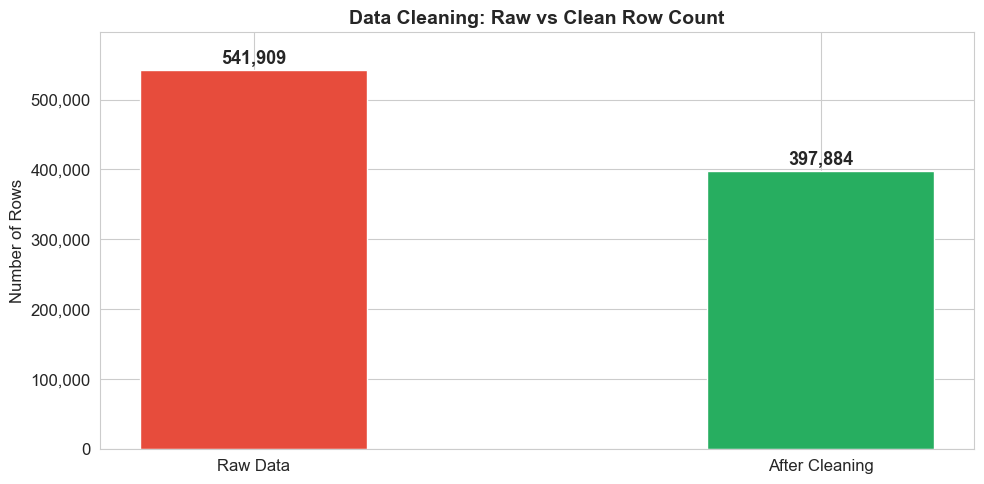

✅ Chart saved: 02_cleaning_summary.png


In [28]:
# CELL 6 — CLEANING SUMMARY TABLE

cleaning_df = pd.DataFrame(cleaning_log)
cleaning_df['Removed'] = cleaning_df['Removed'].apply(lambda x: f"{x:,}")
cleaning_df['Rows']    = cleaning_df['Rows'].apply(lambda x: f"{x:,}")

print("=" * 70)
print("CLEANING EVIDENCE TABLE")
print("=" * 70)
display(cleaning_df[['Stage', 'Rows', 'Removed', 'Rule']])

# Create the charts folder if it does not exist
os.makedirs(CHARTS_FOLDER, exist_ok=True)

# Chart — Before vs After Cleaning
fig, ax = plt.subplots(figsize=(10, 5))
stages  = ['Raw Data', 'After Cleaning']
values  = [df_raw.shape[0], len(df)]
colors  = ['#e74c3c', '#27ae60']
bars = ax.bar(stages, values, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3000,
            f'{val:,}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_title('Data Cleaning: Raw vs Clean Row Count', fontweight='bold')
ax.set_ylabel('Number of Rows')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylim(0, df_raw.shape[0] * 1.1)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_FOLDER, '02_cleaning_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 02_cleaning_summary.png")

In [7]:
#FEATURE ENGINEERING
print("=" * 60)
print("FEATURE ENGINEERING — Creating Analysis Columns")
print("=" * 60)

# Revenue = Quantity × UnitPrice
df['Revenue'] = (df['Quantity'] * df['UnitPrice']).round(2)

# Order Month (YYYY-MM format for grouping)
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')

# Year, Month number, Month name
df['Year']      = df['InvoiceDate'].dt.year
df['MonthNum']  = df['InvoiceDate'].dt.month

# Cohort Month = each customer's FIRST purchase month
cohort_map = df.groupby('CustomerID')['OrderMonth'].min().reset_index()
cohort_map.columns = ['CustomerID', 'CohortMonth']
df = df.merge(cohort_map, on='CustomerID', how='left')

# Months Since First Purchase (0 = first month, 1 = one month later, etc.)
df['MonthsSinceFirst'] = (
    df['OrderMonth'].apply(lambda x: x.ordinal) -
    df['CohortMonth'].apply(lambda x: x.ordinal)
)

print("✅ New columns created:")
print(f"   Revenue          : Quantity × UnitPrice")
print(f"   OrderMonth       : Month of each transaction (Period)")
print(f"   CohortMonth      : Customer's first purchase month")
print(f"   MonthsSinceFirst : Months since first purchase")
print(f"\nSample of enriched data:")
display(df[['CustomerID', 'InvoiceNo', 'OrderMonth', 'CohortMonth',
            'MonthsSinceFirst', 'Revenue']].head(10))

print(f"\nDate range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Total revenue (GBP): £{df['Revenue'].sum():,.2f}")
print(f"Unique customers   : {df['CustomerID'].nunique():,}")
print(f"Unique products    : {df['StockCode'].nunique():,}")
print(f"Unique countries   : {df['Country'].nunique():,}")

FEATURE ENGINEERING — Creating Analysis Columns
✅ New columns created:
   Revenue          : Quantity × UnitPrice
   OrderMonth       : Month of each transaction (Period)
   CohortMonth      : Customer's first purchase month
   MonthsSinceFirst : Months since first purchase

Sample of enriched data:


,CustomerID,InvoiceNo,OrderMonth,CohortMonth,MonthsSinceFirst,Revenue
0,17850,536365,2010-12,2010-12,0,15.30
1,17850,536365,2010-12,2010-12,0,20.34
2,17850,536365,2010-12,2010-12,0,22.00
3,17850,536365,2010-12,2010-12,0,20.34
4,17850,536365,2010-12,2010-12,0,20.34
5,17850,536365,2010-12,2010-12,0,15.30
6,17850,536365,2010-12,2010-12,0,25.50
7,17850,536366,2010-12,2010-12,0,11.10
8,17850,536366,2010-12,2010-12,0,11.10
9,13047,536367,2010-12,2010-12,0,54.08



Date range: 2010-12-01 → 2011-12-09
Total revenue (GBP): £8,911,407.90
Unique customers   : 4,338
Unique products    : 3,665
Unique countries   : 37


In [8]:
#COHORT RETENTION ANALYSIS
print("=" * 60)
print("COHORT RETENTION ANALYSIS")
print("=" * 60)
print("Building cohort retention table...")

# Step 1: Count customers per cohort (M0 = starting size)
cohort_size = df.groupby('CohortMonth')['CustomerID'].nunique().reset_index()
cohort_size.columns = ['CohortMonth', 'CohortSize']

# Step 2: Count active customers per cohort per month offset
cohort_data = df.groupby(['CohortMonth', 'MonthsSinceFirst'])['CustomerID'].nunique().reset_index()
cohort_data.columns = ['CohortMonth', 'MonthOffset', 'ActiveCustomers']

# Step 3: Merge with cohort size to calculate retention %
cohort_data = cohort_data.merge(cohort_size, on='CohortMonth')
cohort_data['RetentionPct'] = (cohort_data['ActiveCustomers'] / cohort_data['CohortSize'] * 100).round(2)

# Step 4: Pivot to wide format (rows=cohort months, columns=M0, M1, M2...)
retention_pivot = cohort_data.pivot_table(
    index='CohortMonth',
    columns='MonthOffset',
    values='RetentionPct'
)
retention_pivot.index = retention_pivot.index.astype(str)
retention_pivot.columns = [f'M{int(c)}' for c in retention_pivot.columns]

print("✅ Cohort retention table created!")
print(f"   Cohorts: {len(retention_pivot)} months")
print(f"   Tracking up to: M{len(retention_pivot.columns)-1}")
print()
display(retention_pivot.style.format("{:.1f}%", na_rep="-"))


COHORT RETENTION ANALYSIS
Building cohort retention table...
✅ Cohort retention table created!
   Cohorts: 13 months
   Tracking up to: M12



,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
CohortMonth,,,,,,,,,,,,,
2010-12,100.0%,36.6%,32.3%,38.4%,36.3%,39.8%,36.3%,34.9%,35.4%,39.5%,37.4%,50.3%,26.6%
2011-01,100.0%,22.1%,26.6%,23.0%,32.1%,28.8%,24.7%,24.2%,30.0%,32.6%,36.5%,11.8%,-
2011-02,100.0%,18.7%,18.7%,28.4%,27.1%,24.7%,25.3%,27.9%,24.7%,30.5%,6.8%,-,-
2011-03,100.0%,15.0%,25.2%,19.9%,22.4%,16.8%,26.8%,23.0%,27.9%,8.6%,-,-,-
2011-04,100.0%,21.3%,20.3%,21.0%,19.7%,22.7%,21.7%,26.0%,7.3%,-,-,-,-
2011-05,100.0%,19.0%,17.2%,17.2%,20.8%,23.2%,26.4%,9.5%,-,-,-,-,-
2011-06,100.0%,17.4%,15.7%,26.4%,23.1%,33.5%,9.5%,-,-,-,-,-,-
2011-07,100.0%,18.1%,20.7%,22.3%,27.1%,11.2%,-,-,-,-,-,-,-
2011-08,100.0%,20.7%,24.9%,24.3%,12.4%,-,-,-,-,-,-,-,-


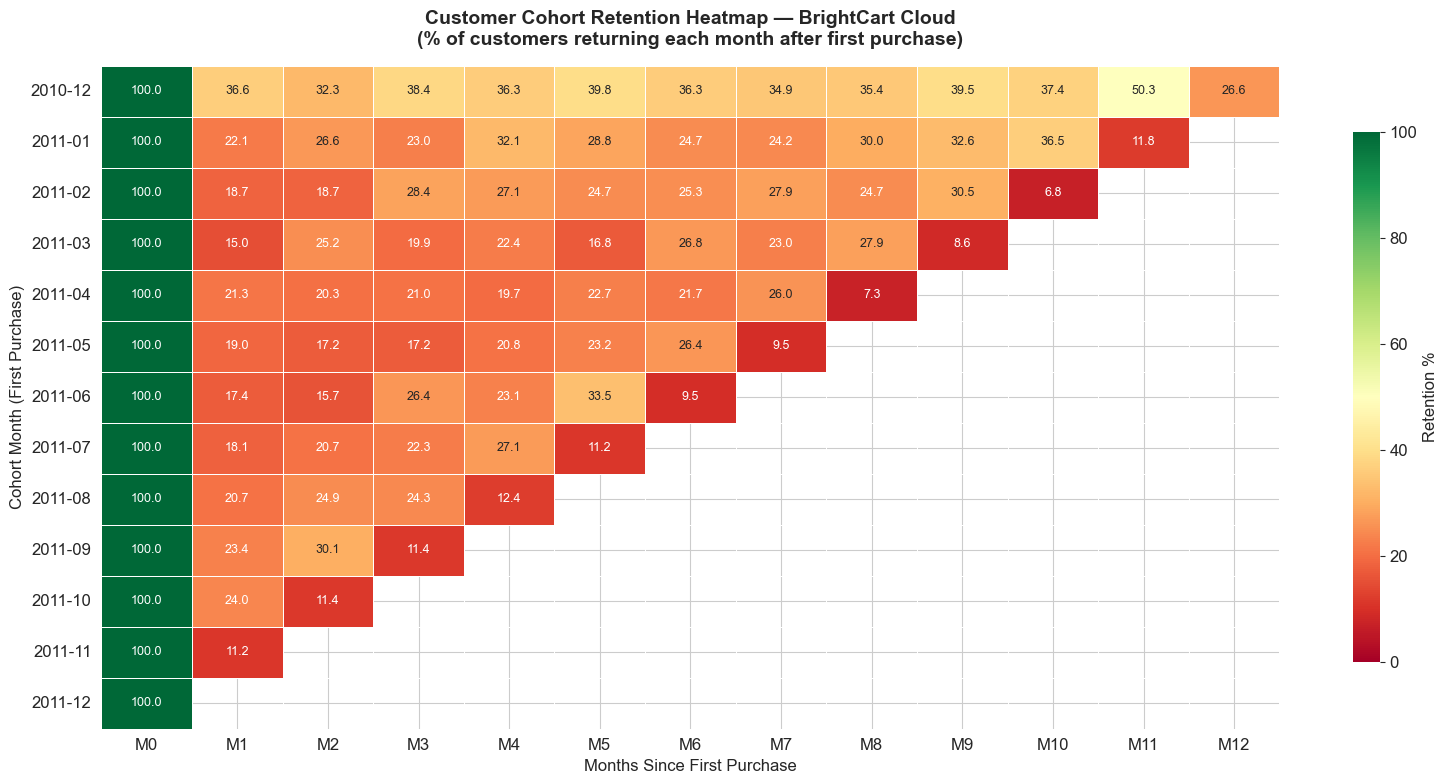

✅ Chart saved: 03_cohort_heatmap.png

 KEY INSIGHT:
   Best M1 retention  : 2010-12 cohort → 36.6%
   Worst M1 retention : 2011-11 cohort → 11.2%


In [10]:
#COHORT RETENTION HEATMAP
cols_to_show = [c for c in retention_pivot.columns if int(c[1:]) <= 12]
heatmap_data = retention_pivot[cols_to_show].copy()

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',         # Red = low retention, Green = high
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=100,
    ax=ax,
    cbar_kws={'label': 'Retention %', 'shrink': 0.8},
    annot_kws={'size': 9}
)

ax.set_title(
    'Customer Cohort Retention Heatmap — BrightCart Cloud\n'
    '(% of customers returning each month after first purchase)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort Month (First Purchase)', fontsize=12)
ax.set_xticklabels(heatmap_data.columns, rotation=0)
ax.set_yticklabels(heatmap_data.index, rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_FOLDER, '03_cohort_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 03_cohort_heatmap.png")

# Key insight print
m1_values = cohort_data[cohort_data['MonthOffset']==1].sort_values('CohortMonth')
if len(m1_values) > 0:
    best  = m1_values.loc[m1_values['RetentionPct'].idxmax()]
    worst = m1_values.loc[m1_values['RetentionPct'].idxmin()]
    print(f"\n KEY INSIGHT:")
    print(f"   Best M1 retention  : {str(best['CohortMonth'])} cohort → {best['RetentionPct']:.1f}%")
    print(f"   Worst M1 retention : {str(worst['CohortMonth'])} cohort → {worst['RetentionPct']:.1f}%")

MONTHLY REVENUE TREND ANALYSIS


,OrderMonth,Total_Revenue,Total_Orders,Active_Customers,Avg_Order_Value
0,2010-12,"572,713.89",1400,885,21.90
1,2011-01,"569,445.04",987,741,26.82
2,2011-02,"447,137.35",997,758,22.44
3,2011-03,"595,500.76",1321,974,21.91
4,2011-04,"469,200.36",1149,856,20.72
5,2011-05,"678,594.56",1555,1056,23.96
6,2011-06,"661,213.69",1393,991,24.32
7,2011-07,"600,091.01",1331,949,22.37
8,2011-08,"645,343.90",1280,935,23.90
9,2011-09,"952,838.38",1755,1266,23.80


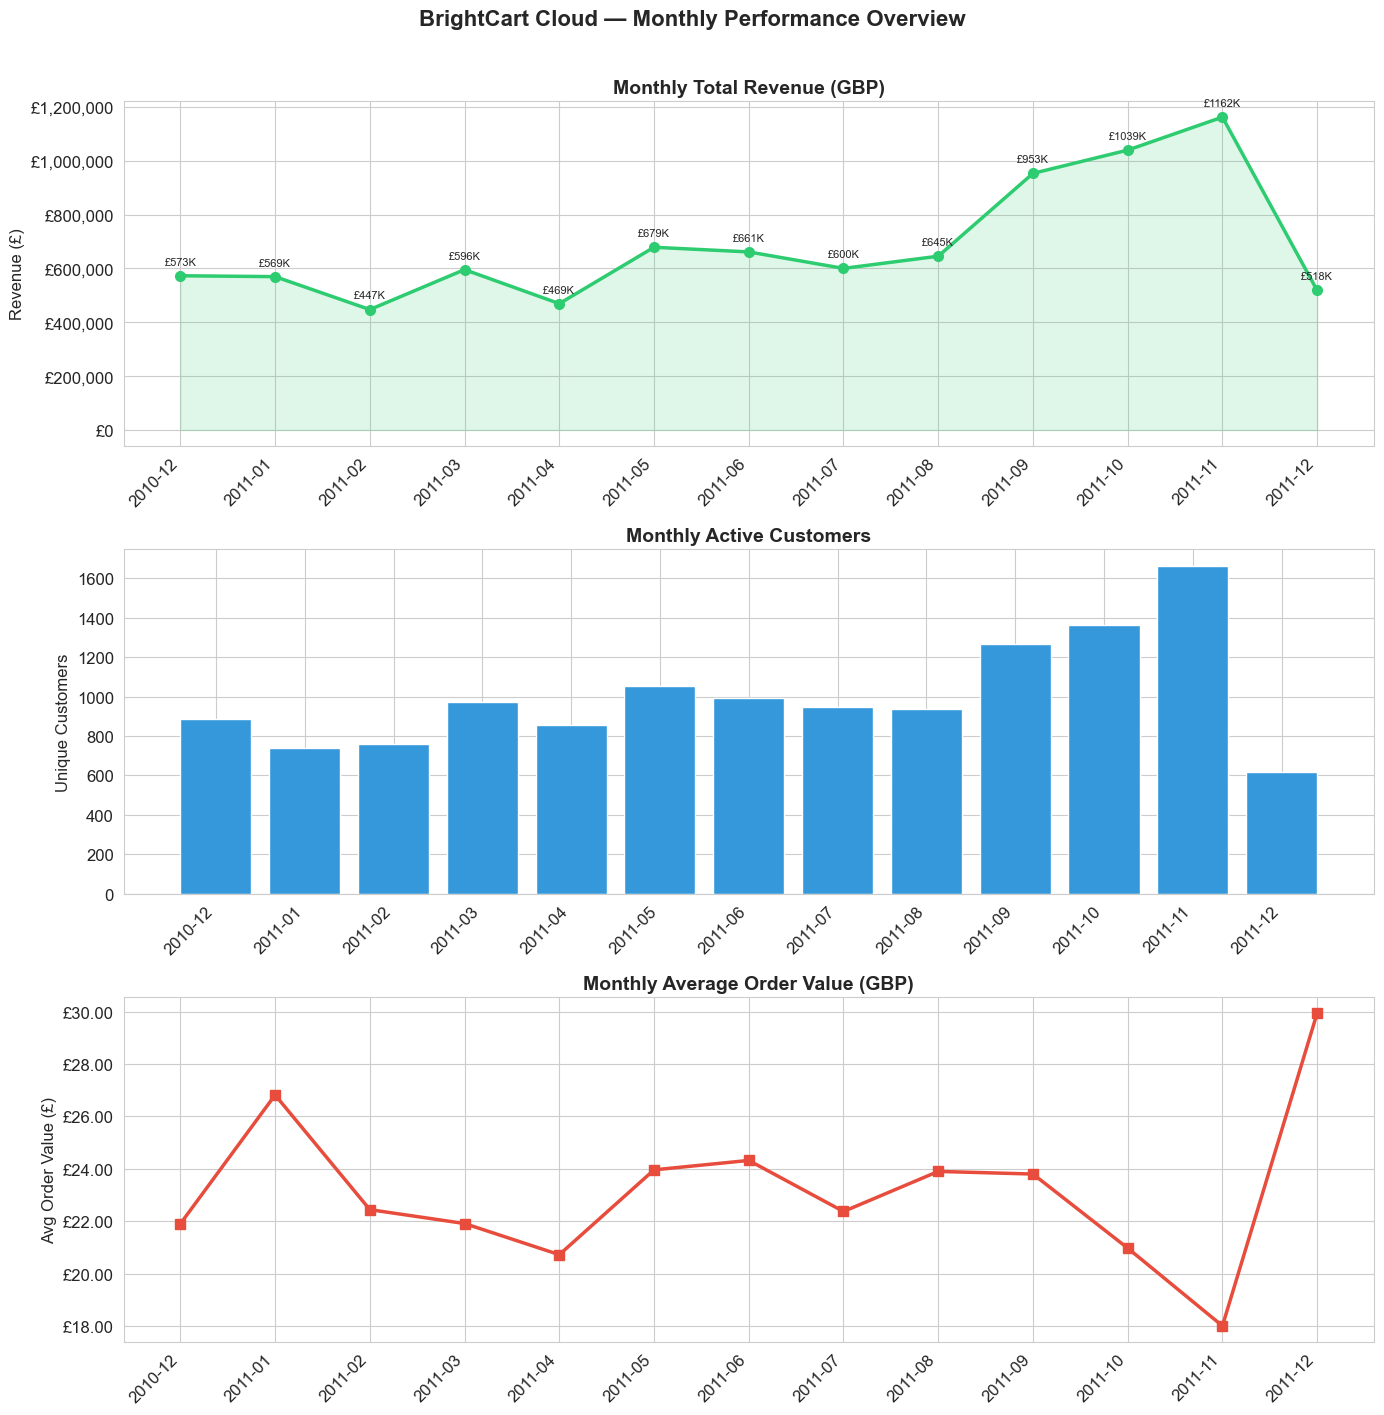

✅ Chart saved: 04_monthly_revenue_trend.png


In [11]:
#MONTHLY REVENUE TREND
print("=" * 60)
print("MONTHLY REVENUE TREND ANALYSIS")
print("=" * 60)

monthly_rev = df.groupby('OrderMonth').agg(
    Total_Revenue   =('Revenue',    'sum'),
    Total_Orders    =('InvoiceNo',  'nunique'),
    Active_Customers=('CustomerID', 'nunique'),
    Avg_Order_Value =('Revenue',    'mean')
).reset_index()

monthly_rev['OrderMonth'] = monthly_rev['OrderMonth'].astype(str)
monthly_rev['Total_Revenue'] = monthly_rev['Total_Revenue'].round(2)
monthly_rev['Avg_Order_Value'] = monthly_rev['Avg_Order_Value'].round(2)

display(monthly_rev)

# Chart — Monthly Revenue
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Plot 1: Total Revenue
axes[0].plot(monthly_rev['OrderMonth'], monthly_rev['Total_Revenue'],
             marker='o', color='#2ecc71', linewidth=2.5, markersize=7)
axes[0].fill_between(range(len(monthly_rev)), monthly_rev['Total_Revenue'],
                      alpha=0.15, color='#2ecc71')
axes[0].set_title('Monthly Total Revenue (GBP)', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].set_xticks(range(len(monthly_rev)))
axes[0].set_xticklabels(monthly_rev['OrderMonth'], rotation=45, ha='right')
for i, row in monthly_rev.iterrows():
    axes[0].annotate(f"£{row['Total_Revenue']/1000:.0f}K",
                     (i, row['Total_Revenue']),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8)

# Plot 2: Active Customers
axes[1].bar(range(len(monthly_rev)), monthly_rev['Active_Customers'],
            color='#3498db', edgecolor='white')
axes[1].set_title('Monthly Active Customers', fontweight='bold')
axes[1].set_ylabel('Unique Customers')
axes[1].set_xticks(range(len(monthly_rev)))
axes[1].set_xticklabels(monthly_rev['OrderMonth'], rotation=45, ha='right')

# Plot 3: Average Order Value
axes[2].plot(monthly_rev['OrderMonth'], monthly_rev['Avg_Order_Value'],
             marker='s', color='#e74c3c', linewidth=2.5, markersize=7)
axes[2].set_title('Monthly Average Order Value (GBP)', fontweight='bold')
axes[2].set_ylabel('Avg Order Value (£)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.2f}'))
axes[2].set_xticks(range(len(monthly_rev)))
axes[2].set_xticklabels(monthly_rev['OrderMonth'], rotation=45, ha='right')

plt.suptitle('BrightCart Cloud — Monthly Performance Overview',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_FOLDER, '04_monthly_revenue_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 04_monthly_revenue_trend.png")


NEW vs REPEAT CUSTOMER REVENUE ANALYSIS
New vs Repeat Revenue Summary:


CustomerType,OrderMonth,New Customer,Repeat Customer
0,2010-12,"572,713.89",0.00
1,2011-01,"293,207.35","276,237.69"
2,2011-02,"158,142.07","288,995.28"
3,2011-03,"200,069.96","395,430.80"
4,2011-04,"122,011.49","347,188.87"
5,2011-05,"124,103.78","554,490.78"
6,2011-06,"135,742.95","525,470.74"
7,2011-07,"74,008.75","526,082.26"
8,2011-08,"79,756.10","565,587.80"
9,2011-09,"155,103.90","797,734.48"



Repeat Customer Rate by Month:


CustomerType,OrderMonth,New Customer,Repeat Customer,Repeat_Rate_Pct
0,2010-12,885.00,0.00,0.00
1,2011-01,417.00,324.00,43.72
2,2011-02,380.00,378.00,49.87
3,2011-03,452.00,522.00,53.59
4,2011-04,300.00,556.00,64.95
5,2011-05,284.00,772.00,73.11
6,2011-06,242.00,749.00,75.58
7,2011-07,188.00,761.00,80.19
8,2011-08,169.00,766.00,81.93
9,2011-09,299.00,967.00,76.38


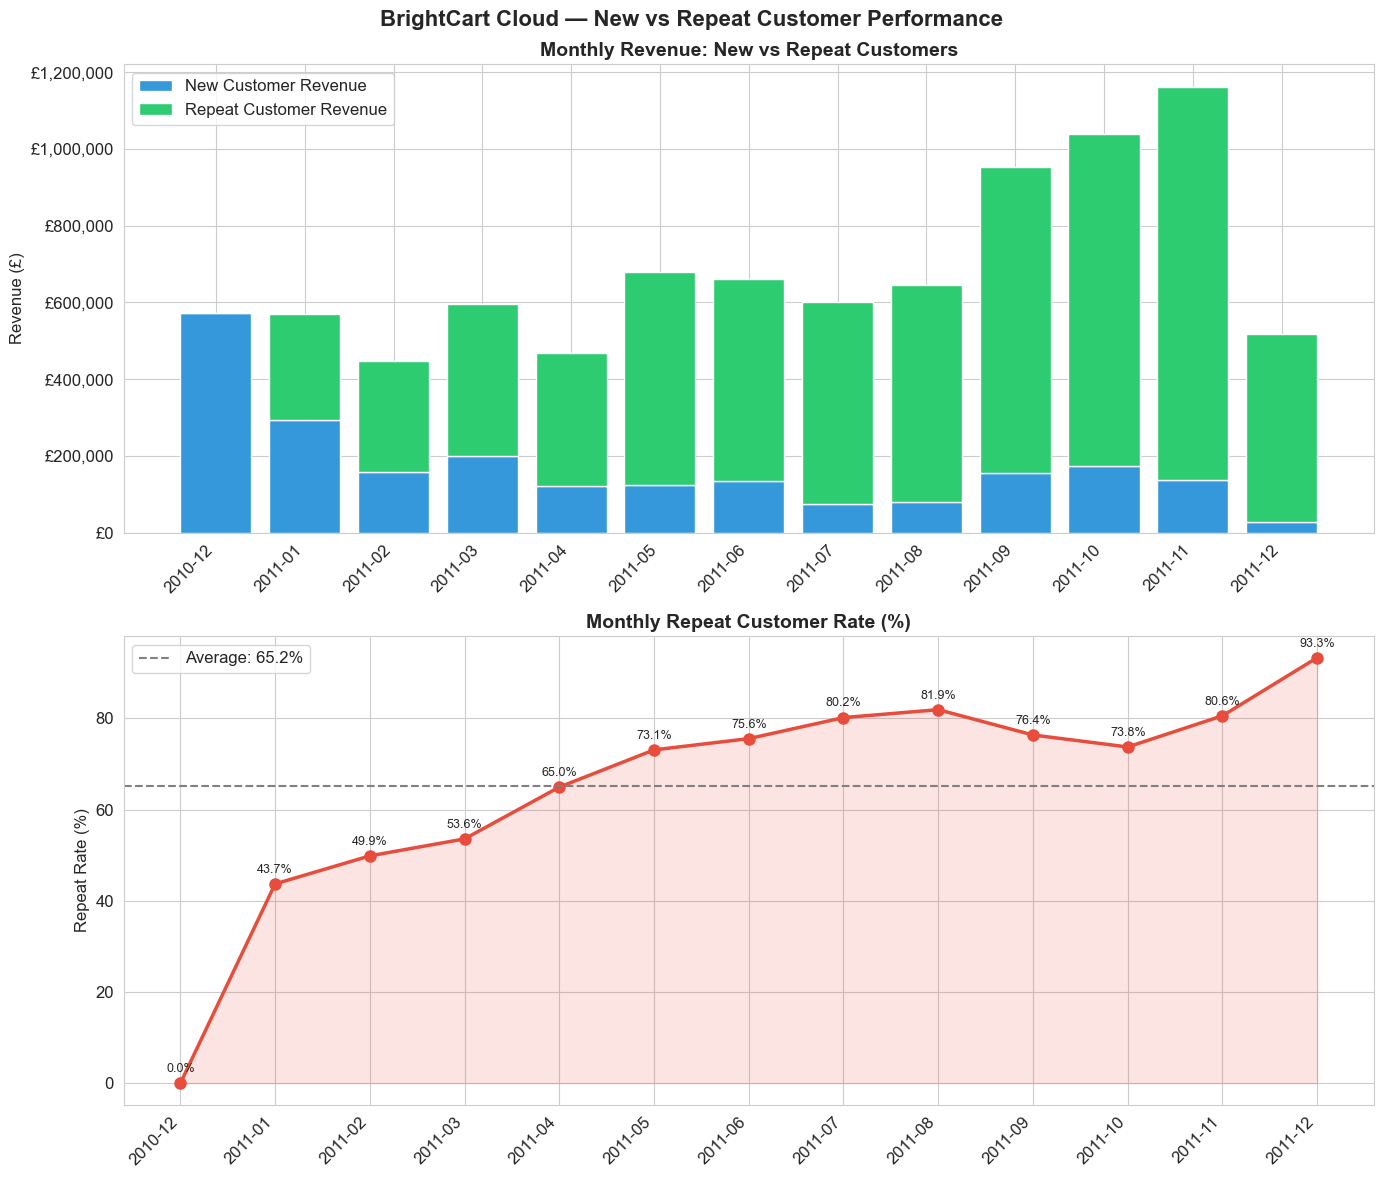

✅ Chart saved: 05_new_vs_repeat_revenue.png


In [12]:
# NEW vs REPEAT CUSTOMER REVENUE
print("=" * 60)
print("NEW vs REPEAT CUSTOMER REVENUE ANALYSIS")
print("=" * 60)

# Tag each order as New (M0) or Repeat (M1+)
df['CustomerType'] = df['MonthsSinceFirst'].apply(
    lambda x: 'New Customer' if x == 0 else 'Repeat Customer'
)

new_vs_repeat = df.groupby(['OrderMonth', 'CustomerType']).agg(
    Revenue   =('Revenue',    'sum'),
    Customers =('CustomerID', 'nunique'),
    Orders    =('InvoiceNo',  'nunique')
).reset_index()

# Pivot for plotting
rev_pivot = new_vs_repeat.pivot_table(
    index='OrderMonth', columns='CustomerType', values='Revenue', aggfunc='sum'
).fillna(0).reset_index()
rev_pivot['OrderMonth'] = rev_pivot['OrderMonth'].astype(str)

cust_pivot = new_vs_repeat.pivot_table(
    index='OrderMonth', columns='CustomerType', values='Customers', aggfunc='sum'
).fillna(0).reset_index()
cust_pivot['OrderMonth'] = cust_pivot['OrderMonth'].astype(str)

# Repeat Rate
cust_pivot['Repeat_Rate_Pct'] = (
    cust_pivot.get('Repeat Customer', 0) /
    (cust_pivot.get('New Customer', 0) + cust_pivot.get('Repeat Customer', 0)) * 100
).round(2)

print("New vs Repeat Revenue Summary:")
display(rev_pivot)
print("\nRepeat Customer Rate by Month:")
display(cust_pivot[['OrderMonth', 'New Customer', 'Repeat Customer', 'Repeat_Rate_Pct']])

# Chart — Stacked Bar Revenue
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

x = range(len(rev_pivot))
new_rev    = rev_pivot.get('New Customer', pd.Series([0]*len(rev_pivot)))
repeat_rev = rev_pivot.get('Repeat Customer', pd.Series([0]*len(rev_pivot)))

axes[0].bar(x, new_rev,    label='New Customer Revenue',
            color='#3498db', edgecolor='white')
axes[0].bar(x, repeat_rev, bottom=new_rev, label='Repeat Customer Revenue',
            color='#2ecc71', edgecolor='white')
axes[0].set_title('Monthly Revenue: New vs Repeat Customers', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].set_xticks(x)
axes[0].set_xticklabels(rev_pivot['OrderMonth'], rotation=45, ha='right')
axes[0].legend(loc='upper left')

# Chart — Repeat Rate Line
axes[1].plot(x, cust_pivot['Repeat_Rate_Pct'],
             marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
axes[1].fill_between(x, cust_pivot['Repeat_Rate_Pct'], alpha=0.15, color='#e74c3c')
axes[1].set_title('Monthly Repeat Customer Rate (%)', fontweight='bold')
axes[1].set_ylabel('Repeat Rate (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cust_pivot['OrderMonth'], rotation=45, ha='right')
axes[1].axhline(y=cust_pivot['Repeat_Rate_Pct'].mean(), color='gray',
                linestyle='--', linewidth=1.5, label=f"Average: {cust_pivot['Repeat_Rate_Pct'].mean():.1f}%")
axes[1].legend()
for i, val in enumerate(cust_pivot['Repeat_Rate_Pct']):
    axes[1].annotate(f"{val:.1f}%", (i, val),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=9)

plt.suptitle('BrightCart Cloud — New vs Repeat Customer Performance',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_FOLDER, '05_new_vs_repeat_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 05_new_vs_repeat_revenue.png")

In [13]:
#RFM ANALYSIS (Recency, Frequency, Monetary)
print("=" * 60)
print("RFM ANALYSIS — Customer Scoring")
print("=" * 60)

REFERENCE_DATE = pd.Timestamp('2011-12-10')  # 1 day after last transaction

# Calculate R, F, M per customer
rfm = df.groupby('CustomerID').agg(
    Recency  =('InvoiceDate', lambda x: (REFERENCE_DATE - x.max()).days),
    Frequency=('InvoiceNo',   'nunique'),
    Monetary =('Revenue',     'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

# Score each metric 1-4 using quartiles (4 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'],  q=4, labels=[4, 3, 2, 1]).astype(int)  # Lower days = score 4
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1, 2, 3, 4]).astype(int)

rfm['RFM_Total']  = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm['RFM_String'] = rfm['R_Score'].astype(str) + '-' + \
                    rfm['F_Score'].astype(str) + '-' + \
                    rfm['M_Score'].astype(str)

print("✅ RFM scores calculated!")
print(f"\nRFM Summary Statistics:")
display(rfm[['Recency', 'Frequency', 'Monetary', 'RFM_Total']].describe().round(2))
print(f"\nSample RFM Table (Top 10 by Monetary):")
display(rfm.sort_values('Monetary', ascending=False).head(10))


RFM ANALYSIS — Customer Scoring
✅ RFM scores calculated!

RFM Summary Statistics:


,Recency,Frequency,Monetary,RFM_Total
count,"4,338.00","4,338.00","4,338.00","4,338.00"
mean,92.06,4.27,"2,054.27",7.51
std,100.01,7.70,"8,989.23",2.83
min,0.00,1.00,3.75,3.00
25%,17.00,1.00,307.41,5.00
50%,50.00,2.00,674.48,7.00
75%,141.75,5.00,"1,661.74",10.00
max,373.00,209.00,"280,206.02",12.00



Sample RFM Table (Top 10 by Monetary):


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,RFM_String
1689,14646,1,73,"280,206.02",4,4,4,12,4-4-4
4201,18102,0,60,"259,657.30",4,4,4,12,4-4-4
3728,17450,8,46,"194,550.79",4,4,4,12,4-4-4
3008,16446,0,2,"168,472.50",4,2,4,10,4-2-4
1879,14911,1,201,"143,825.06",4,4,4,12,4-4-4
55,12415,24,21,"124,914.53",3,4,4,11,3-4-4
1333,14156,9,55,"117,379.63",4,4,4,12,4-4-4
3771,17511,2,31,"91,062.38",4,4,4,12,4-4-4
2702,16029,38,63,"81,024.84",3,4,4,11,3-4-4
0,12346,325,1,"77,183.60",1,1,4,6,1-1-4


In [14]:
#CUSTOMER SEGMENTATION
print("=" * 60)
print("CUSTOMER SEGMENTATION — Assigning Segments")
print("=" * 60)

def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r == 4 and f == 4 and m == 4:
        return 'Champions'
    elif f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk — High Value'
    elif r == 1 and m >= 3:
        return 'Lost — High Value'
    elif r >= 3 and f <= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r == 4 and f == 1:
        return 'New Customers'
    elif r == 2 and f <= 2:
        return 'About to Sleep'
    else:
        return 'Dormant / Lost'

def assign_action(row):
    seg = row['Segment']
    actions = {
        'Champions'          : 'Reward & upsell — highest priority',
        'Loyal Customers'    : 'Loyalty programme — keep engaged',
        'At Risk — High Value': 'Win-back campaign — URGENT',
        'Lost — High Value'  : 'Win-back with strong incentive',
        'Potential Loyalists': 'Nurture to second purchase',
        'New Customers'      : 'Onboarding email sequence',
        'About to Sleep'     : 'Re-engagement campaign',
        'Dormant / Lost'     : 'Low priority — survey or remove',
    }
    return actions.get(seg, 'Review')

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
rfm['Action']  = rfm.apply(assign_action,  axis=1)

# Segment Summary
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count       =('CustomerID', 'count'),
    Avg_Recency_Days     =('Recency',    'mean'),
    Avg_Orders           =('Frequency',  'mean'),
    Avg_Revenue          =('Monetary',   'mean'),
    Total_Segment_Revenue=('Monetary',   'sum')
).round(2).sort_values('Total_Segment_Revenue', ascending=False).reset_index()

segment_summary['Pct_of_Customers'] = (
    segment_summary['Customer_Count'] / segment_summary['Customer_Count'].sum() * 100
).round(1)

print("CUSTOMER SEGMENT DISTRIBUTION:")
display(segment_summary)


CUSTOMER SEGMENTATION — Assigning Segments
CUSTOMER SEGMENT DISTRIBUTION:


,Segment,Customer_Count,Avg_Recency_Days,Avg_Orders,Avg_Revenue,Total_Segment_Revenue,Pct_of_Customers
0,Champions,483,6.78,15.64,"9,144.96","4,417,015.93",11.10
1,Loyal Customers,1284,51.32,5.38,"2,372.96","3,046,879.95",29.60
2,Potential Loyalists,385,24.38,1.60,"1,160.72","446,878.29",8.90
3,Dormant / Lost,1421,171.19,1.71,304.87,"433,219.75",32.80
4,About to Sleep,608,82.98,1.32,552.69,"336,036.91",14.00
5,Lost — High Value,114,234.12,1.56,"1,961.18","223,574.64",2.60
6,New Customers,43,9.21,1.00,181.45,"7,802.43",1.00


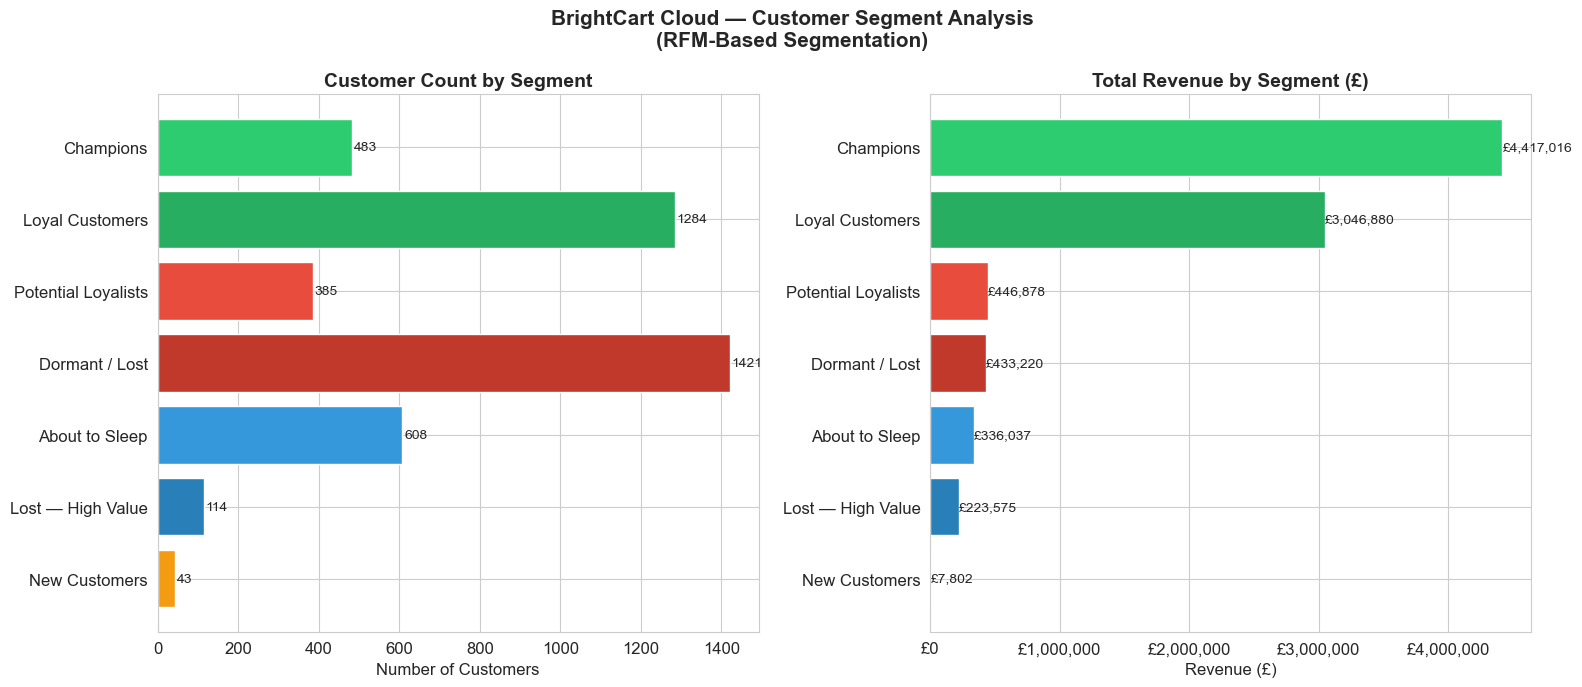

✅ Chart saved: 06_customer_segments.png


In [15]:
#SEGMENT CHARTS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Customer Count by Segment
colors_seg = ['#2ecc71','#27ae60','#e74c3c','#c0392b','#3498db','#2980b9','#f39c12','#d35400']
bars = axes[0].barh(
    segment_summary['Segment'],
    segment_summary['Customer_Count'],
    color=colors_seg[:len(segment_summary)],
    edgecolor='white'
)
for bar in bars:
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.0f}', va='center', fontsize=10)
axes[0].set_title('Customer Count by Segment', fontweight='bold')
axes[0].set_xlabel('Number of Customers')
axes[0].invert_yaxis()

# Chart 2: Total Revenue by Segment
bars2 = axes[1].barh(
    segment_summary['Segment'],
    segment_summary['Total_Segment_Revenue'],
    color=colors_seg[:len(segment_summary)],
    edgecolor='white'
)
for bar in bars2:
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'£{bar.get_width():,.0f}', va='center', fontsize=10)
axes[1].set_title('Total Revenue by Segment (£)', fontweight='bold')
axes[1].set_xlabel('Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].invert_yaxis()

plt.suptitle('BrightCart Cloud — Customer Segment Analysis\n(RFM-Based Segmentation)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_FOLDER, '06_customer_segments.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 06_customer_segments.png")

AT-RISK HIGH VALUE CUSTOMERS
Business Question: Who are the high-value customers
                   that are declining in purchases?
Total at-risk high-value customers: 114
Total revenue at risk: £223,574.64
Average days since last purchase: 234 days

Top 15 At-Risk High-Value Customers:


,CustomerID,Recency,Frequency,Monetary,RFM_String,Segment,Action
0,12346,325,1,"77,183.60",1-1-4,Lost — High Value,Win-back with strong incentive
196,12590,211,2,"9,864.26",1-2-4,Lost — High Value,Win-back with strong incentive
332,12755,280,2,"3,811.95",1-2-4,Lost — High Value,Win-back with strong incentive
1185,13952,217,2,"3,251.07",1-2-4,Lost — High Value,Win-back with strong incentive
597,13135,196,1,"3,096.00",1-1-4,Lost — High Value,Win-back with strong incentive
227,12625,211,2,"2,683.82",1-2-4,Lost — High Value,Win-back with strong incentive
1533,14439,319,1,"2,661.24",1-1-4,Lost — High Value,Win-back with strong incentive
2440,15665,168,2,"2,242.01",1-2-4,Lost — High Value,Win-back with strong incentive
251,12653,148,2,"2,209.85",1-2-4,Lost — High Value,Win-back with strong incentive
123,12501,336,1,"2,169.39",1-1-4,Lost — High Value,Win-back with strong incentive


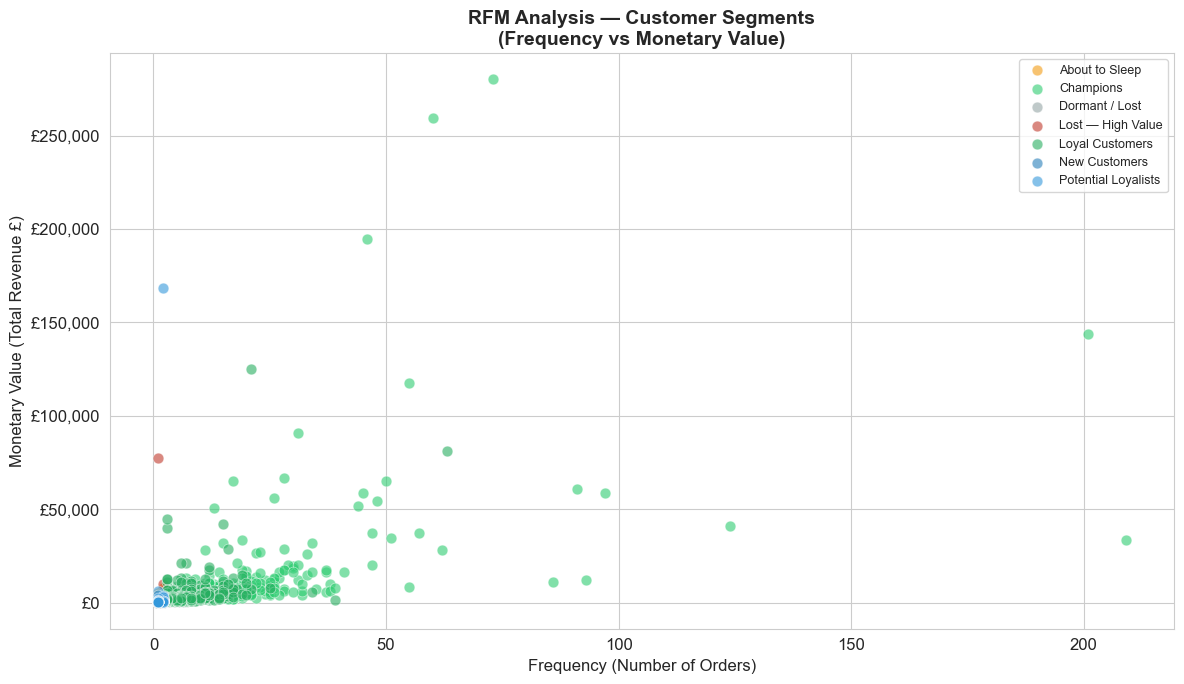

✅ Chart saved: 07_rfm_scatter.png


In [16]:
#AT-RISK HIGH VALUE CUSTOMERS
print("=" * 60)
print("AT-RISK HIGH VALUE CUSTOMERS")
print("Business Question: Who are the high-value customers")
print("                   that are declining in purchases?")
print("=" * 60)

at_risk = rfm[rfm['Segment'].isin(['At Risk — High Value', 'Lost — High Value'])]\
    .sort_values('Monetary', ascending=False)

print(f"Total at-risk high-value customers: {len(at_risk):,}")
print(f"Total revenue at risk: £{at_risk['Monetary'].sum():,.2f}")
print(f"Average days since last purchase: {at_risk['Recency'].mean():.0f} days")
print()
print("Top 15 At-Risk High-Value Customers:")
display(at_risk[['CustomerID', 'Recency', 'Frequency', 'Monetary',
                 'RFM_String', 'Segment', 'Action']].head(15))

# RFM Scatter Plot
fig, ax = plt.subplots(figsize=(12, 7))
segment_colors = {
    'Champions'          : '#2ecc71',
    'Loyal Customers'    : '#27ae60',
    'At Risk — High Value': '#e74c3c',
    'Lost — High Value'  : '#c0392b',
    'Potential Loyalists': '#3498db',
    'New Customers'      : '#2980b9',
    'About to Sleep'     : '#f39c12',
    'Dormant / Lost'     : '#95a5a6',
}

for seg, group in rfm.groupby('Segment'):
    ax.scatter(
        group['Frequency'],
        group['Monetary'],
        c=segment_colors.get(seg, 'gray'),
        label=seg,
        alpha=0.6,
        s=60,
        edgecolors='white',
        linewidth=0.5
    )

ax.set_title('RFM Analysis — Customer Segments\n(Frequency vs Monetary Value)',
             fontweight='bold')
ax.set_xlabel('Frequency (Number of Orders)')
ax.set_ylabel('Monetary Value (Total Revenue £)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_FOLDER, '07_rfm_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 07_rfm_scatter.png")

PRODUCT ANALYSIS
Business Question: Which PRODUCTS to prioritize?
TOP 15 PRODUCTS BY REVENUE:


,StockCode,Description,Unique_Buyers,Total_Orders,Total_Revenue,Repeat_Rate_Pct
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",1,1,"168,469.60",0.00
1318,22423,REGENCY CAKESTAND 3 TIER,881,1703,"142,592.95",37.46
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,856,1971,"100,448.15",47.55
3444,85099B,JUMBO BAG RED RETROSPOT,635,1600,"85,220.78",49.13
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,138,195,"81,416.73",18.12
3896,POST,POSTAGE,331,1099,"77,803.96",57.10
2799,47566,PARTY BUNTING,708,1379,"68,844.33",39.55
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,678,1375,"56,580.34",42.92
3894,M,Manual,197,253,"53,779.93",14.72
2006,23084,RABBIT NIGHT LIGHT,450,801,"51,346.20",40.67


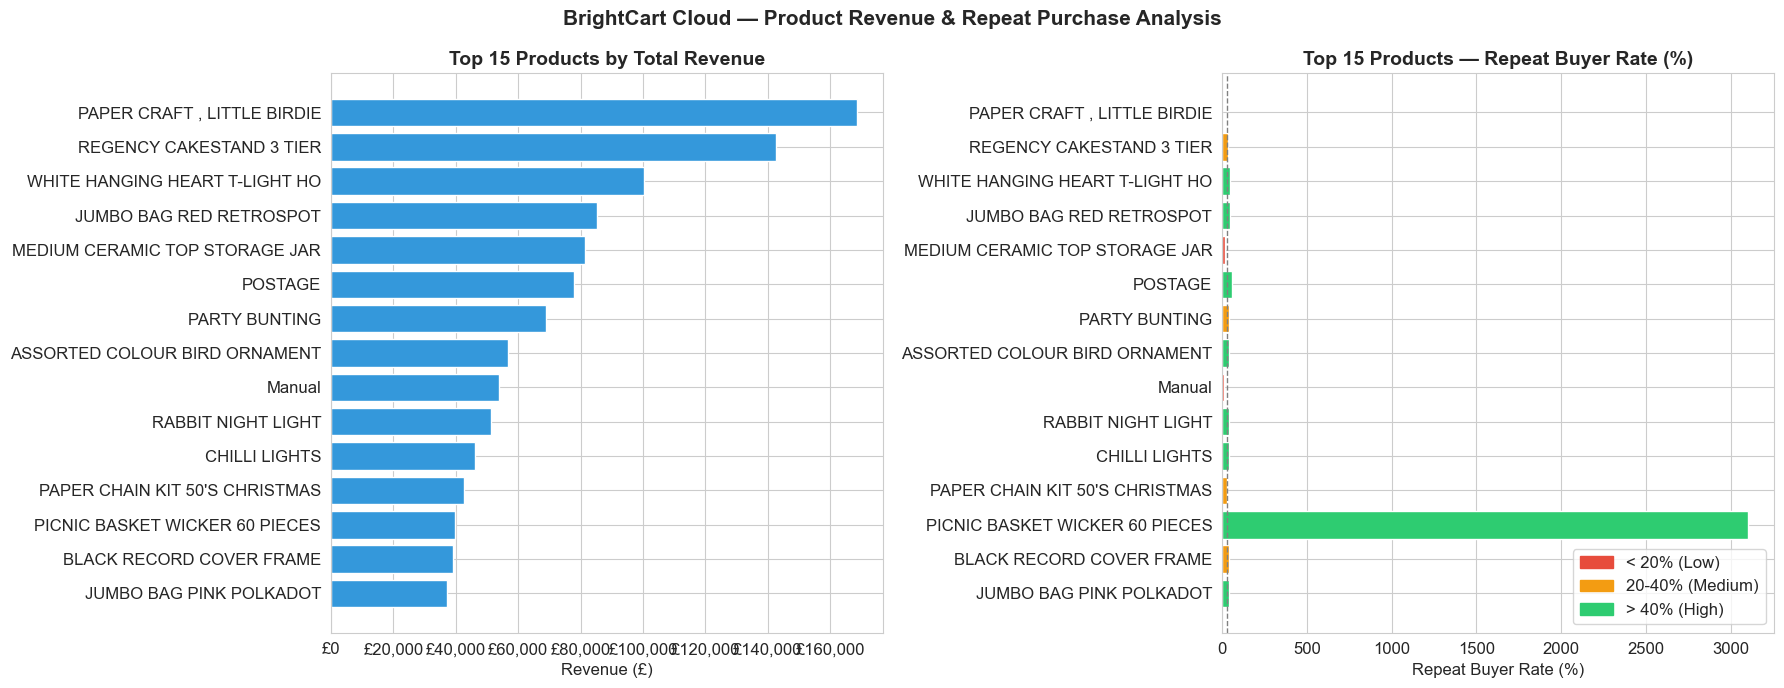

✅ Chart saved: 08_product_analysis.png


In [17]:
#PRODUCT ANALYSIS
print("=" * 60)
print("PRODUCT ANALYSIS")
print("Business Question: Which PRODUCTS to prioritize?")
print("=" * 60)

product_summary = df.groupby(['StockCode', 'Description']).agg(
    Unique_Buyers=('CustomerID', 'nunique'),
    Total_Orders =('InvoiceNo',  'nunique'),
    Total_Revenue=('Revenue',    'sum'),
    Total_Qty    =('Quantity',   'sum'),
    Avg_Price    =('UnitPrice',  'mean')
).reset_index().round(2)

# Repeat buyer rate per product
product_customer_orders = df.groupby(['StockCode', 'CustomerID'])['InvoiceNo'].nunique().reset_index()
product_customer_orders.columns = ['StockCode', 'CustomerID', 'Cust_Order_Count']
repeat_buyers = product_customer_orders[product_customer_orders['Cust_Order_Count'] > 1]\
    .groupby('StockCode')['CustomerID'].nunique().reset_index()
repeat_buyers.columns = ['StockCode', 'Repeat_Buyers']

product_summary = product_summary.merge(repeat_buyers, on='StockCode', how='left')
product_summary['Repeat_Buyers']   = product_summary['Repeat_Buyers'].fillna(0).astype(int)
product_summary['Repeat_Rate_Pct'] = (
    product_summary['Repeat_Buyers'] / product_summary['Unique_Buyers'] * 100
).round(2)

product_summary = product_summary.sort_values('Total_Revenue', ascending=False)

print("TOP 15 PRODUCTS BY REVENUE:")
display(product_summary.head(15)[['StockCode', 'Description', 'Unique_Buyers',
                                   'Total_Orders', 'Total_Revenue', 'Repeat_Rate_Pct']])

# Chart — Top 15 Products
top15 = product_summary.head(15).copy()
top15['Short_Name'] = top15['Description'].str[:30]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Revenue bar
bars = axes[0].barh(top15['Short_Name'][::-1], top15['Total_Revenue'][::-1],
                    color='#3498db', edgecolor='white')
axes[0].set_title('Top 15 Products by Total Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Repeat Rate bar
color_repeat = ['#e74c3c' if r < 20 else '#f39c12' if r < 40 else '#2ecc71'
                for r in top15['Repeat_Rate_Pct'][::-1]]
bars2 = axes[1].barh(top15['Short_Name'][::-1], top15['Repeat_Rate_Pct'][::-1],
                     color=color_repeat, edgecolor='white')
axes[1].set_title('Top 15 Products — Repeat Buyer Rate (%)', fontweight='bold')
axes[1].set_xlabel('Repeat Buyer Rate (%)')
axes[1].axvline(x=30, color='gray', linestyle='--', linewidth=1, label='30% threshold')
axes[1].legend()

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='< 20% (Low)'),
    mpatches.Patch(color='#f39c12', label='20-40% (Medium)'),
    mpatches.Patch(color='#2ecc71', label='> 40% (High)'),
]
axes[1].legend(handles=legend_patches, loc='lower right')

plt.suptitle('BrightCart Cloud — Product Revenue & Repeat Purchase Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_FOLDER, '08_product_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 08_product_analysis.png")


COUNTRY ANALYSIS
Business Question: Which COUNTRIES to prioritize?
COUNTRY REVENUE SUMMARY (Top 15):


,Country,Unique_Customers,Total_Orders,Total_Revenue,Avg_Order_Value,Repeat_Customers,Repeat_Rate_Pct,Revenue_Per_Customer
35,United Kingdom,3920,16646,"7,308,391.55",20.63,2570,65.56,"1,864.39"
23,Netherlands,9,94,"285,446.34",121.00,5,55.56,"31,716.26"
10,EIRE,3,260,"265,545.90",36.70,3,100.00,"88,515.30"
14,Germany,94,457,"228,867.14",25.32,68,72.34,"2,434.76"
13,France,87,389,"209,024.05",25.06,59,67.82,"2,402.58"
0,Australia,9,57,"138,521.31",117.19,9,100.00,"15,391.26"
30,Spain,30,90,"61,577.11",24.79,18,60.00,"2,052.57"
32,Switzerland,21,51,"56,443.95",30.66,15,71.43,"2,687.81"
3,Belgium,25,98,"41,196.34",20.28,18,72.00,"1,647.85"
31,Sweden,8,36,"38,378.33",85.10,4,50.00,"4,797.29"


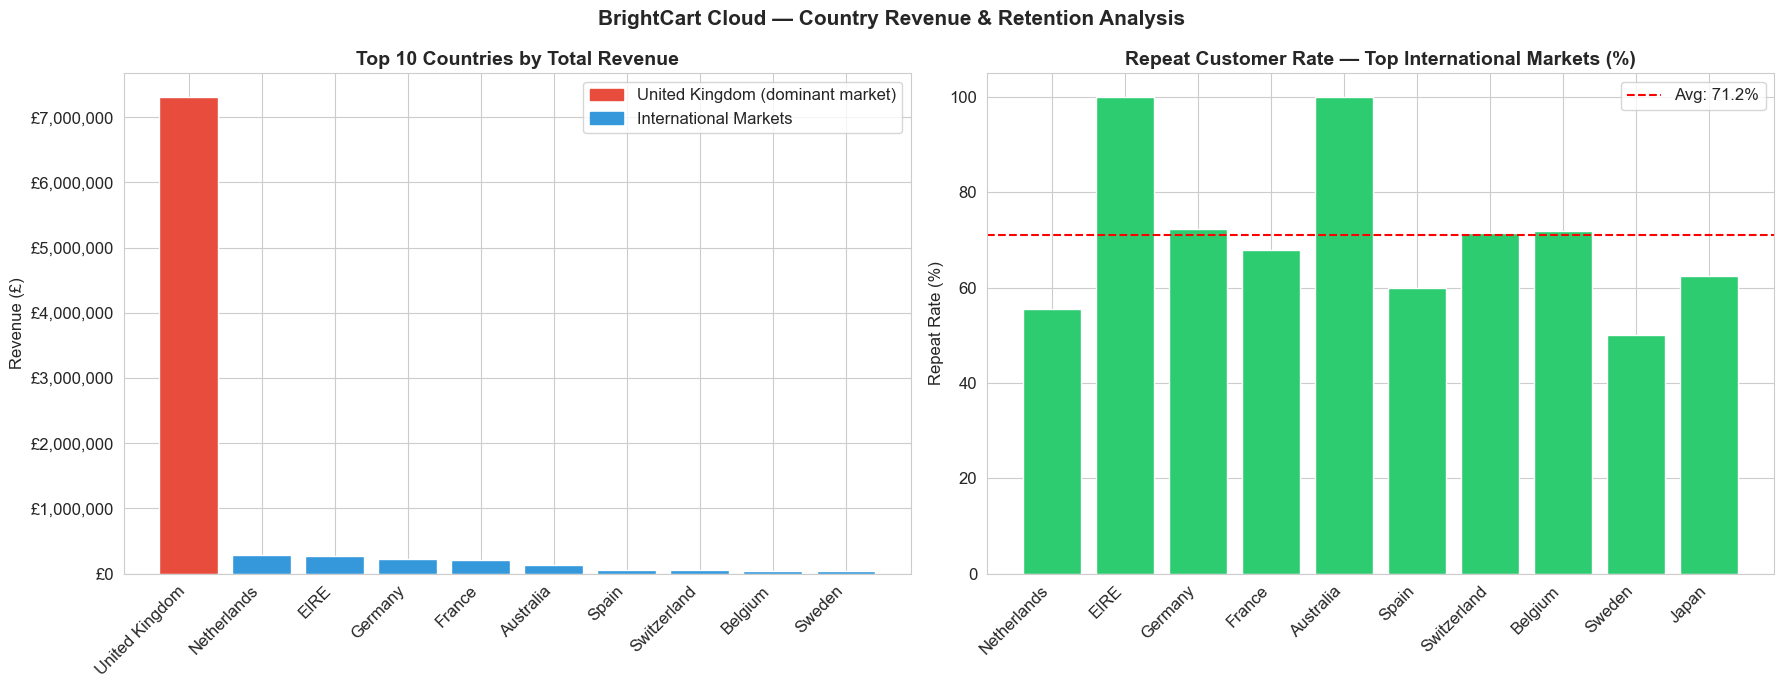

✅ Chart saved: 09_country_analysis.png


In [18]:
#COUNTRY ANALYSIS
print("=" * 60)
print("COUNTRY ANALYSIS")
print("Business Question: Which COUNTRIES to prioritize?")
print("=" * 60)

country_summary = df.groupby('Country').agg(
    Unique_Customers=('CustomerID', 'nunique'),
    Total_Orders    =('InvoiceNo',  'nunique'),
    Total_Revenue   =('Revenue',    'sum'),
    Avg_Order_Value =('Revenue',    'mean')
).reset_index().round(2)

# Add repeat customer count per country
repeat_customers_country = df.groupby('CustomerID').agg(
    Country      =('Country', 'first'),
    Total_Orders =('InvoiceNo', 'nunique')
).reset_index()

repeat_by_country = repeat_customers_country[repeat_customers_country['Total_Orders'] > 1]\
    .groupby('Country').size().reset_index(name='Repeat_Customers')

country_summary = country_summary.merge(repeat_by_country, on='Country', how='left')
country_summary['Repeat_Customers']   = country_summary['Repeat_Customers'].fillna(0).astype(int)
country_summary['Repeat_Rate_Pct']    = (
    country_summary['Repeat_Customers'] / country_summary['Unique_Customers'] * 100
).round(2)
country_summary['Revenue_Per_Customer'] = (
    country_summary['Total_Revenue'] / country_summary['Unique_Customers']
).round(2)

country_summary = country_summary.sort_values('Total_Revenue', ascending=False)

print("COUNTRY REVENUE SUMMARY (Top 15):")
display(country_summary.head(15))

# Chart — Country Analysis
top_countries = country_summary.head(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Revenue by country
colors_country = ['#e74c3c' if c == 'United Kingdom' else '#3498db'
                  for c in top_countries['Country']]
bars = axes[0].bar(range(len(top_countries)), top_countries['Total_Revenue'],
                   color=colors_country, edgecolor='white')
axes[0].set_xticks(range(len(top_countries)))
axes[0].set_xticklabels(top_countries['Country'], rotation=45, ha='right')
axes[0].set_title('Top 10 Countries by Total Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

uk_patch  = mpatches.Patch(color='#e74c3c', label='United Kingdom (dominant market)')
int_patch = mpatches.Patch(color='#3498db', label='International Markets')
axes[0].legend(handles=[uk_patch, int_patch])

# Repeat Rate by Country (ex UK to show smaller markets clearly)
intl = country_summary[country_summary['Country'] != 'United Kingdom'].head(10)
axes[1].bar(range(len(intl)), intl['Repeat_Rate_Pct'],
            color='#2ecc71', edgecolor='white')
axes[1].set_xticks(range(len(intl)))
axes[1].set_xticklabels(intl['Country'], rotation=45, ha='right')
axes[1].set_title('Repeat Customer Rate — Top International Markets (%)',
                  fontweight='bold')
axes[1].set_ylabel('Repeat Rate (%)')
axes[1].axhline(y=intl['Repeat_Rate_Pct'].mean(), color='red',
                linestyle='--', label=f"Avg: {intl['Repeat_Rate_Pct'].mean():.1f}%")
axes[1].legend()

plt.suptitle('BrightCart Cloud — Country Revenue & Retention Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_FOLDER, '09_country_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: 09_country_analysis.png")

In [19]:
#SAVE RFM TABLE FOR POWER BI
# Merge RFM with country info
df_customer_info = df.groupby('CustomerID').agg(
    Country      =('Country',     'first'),
    CohortMonth  =('CohortMonth', 'first'),
    LastOrderDate=('InvoiceDate', 'max'),
    FirstOrderDate=('InvoiceDate','min')
).reset_index()

rfm_final = rfm.merge(df_customer_info, on='CustomerID', how='left')

# Save to CSV for Power BI
EXPORT_PATH = r"C:\Users\Admin\Desktop\Codezela\Data Analyst session - Final Project"

rfm_final.to_csv(
    os.path.join(EXPORT_PATH, 'python_customer_segments.csv'),
    index=False
)
print("✅ Saved: python_customer_segments.csv")

monthly_rev_export = df.groupby(['OrderMonth', 'CustomerType']).agg(
    Revenue  =('Revenue',    'sum'),
    Customers=('CustomerID', 'nunique'),
    Orders   =('InvoiceNo',  'nunique')
).reset_index()
monthly_rev_export['OrderMonth'] = monthly_rev_export['OrderMonth'].astype(str)
monthly_rev_export.to_csv(
    os.path.join(EXPORT_PATH, 'python_monthly_new_vs_repeat.csv'),
    index=False
)
print("✅ Saved: python_monthly_new_vs_repeat.csv")

product_summary.to_csv(
    os.path.join(EXPORT_PATH, 'python_product_summary.csv'),
    index=False
)
print("✅ Saved: python_product_summary.csv")

country_summary.to_csv(
    os.path.join(EXPORT_PATH, 'python_country_summary.csv'),
    index=False
)
print("✅ Saved: python_country_summary.csv")

retention_pivot.to_csv(
    os.path.join(EXPORT_PATH, 'python_cohort_heatmap.csv')
)
print("✅ Saved: python_cohort_heatmap.csv")

print("\n✅ ALL EXPORT FILES SAVED SUCCESSFULLY!")

✅ Saved: python_customer_segments.csv
✅ Saved: python_monthly_new_vs_repeat.csv
✅ Saved: python_product_summary.csv
✅ Saved: python_country_summary.csv
✅ Saved: python_cohort_heatmap.csv

✅ ALL EXPORT FILES SAVED SUCCESSFULLY!


In [21]:
#KEY FINDINGS SUMMARY 
print("=" * 70)
print("KEY FINDINGS — ANSWERING THE BUSINESS QUESTION")
print("=" * 70)
print("""
BUSINESS QUESTION:
  Why are repeat purchases declining among previously high-value customers,
  and which products, countries, and customer segments should the company
  prioritize to improve long-term revenue retention?
""")

# Finding 1: Retention trend
early_cohorts = [str(c) for c in retention_pivot.index[:3]]
late_cohorts  = [str(c) for c in retention_pivot.index[-3:]]
early_m1 = retention_pivot.loc[early_cohorts, 'M1'].mean() if 'M1' in retention_pivot.columns else 0
late_m1  = retention_pivot.loc[late_cohorts,  'M1'].mean() if 'M1' in retention_pivot.columns else 0

print(f"FINDING 1 — RETENTION IS DECLINING")
print(f"  Early cohorts (first 3 months) M1 retention avg : {early_m1:.1f}%")
print(f"  Later cohorts (last 3 months) M1 retention avg  : {late_m1:.1f}%")
print(f"  Trend: Retention is {'DECLINING ⬇️' if late_m1 < early_m1 else 'IMPROVING ⬆️'}")
print()

# Finding 2: At-risk customers
at_risk_count   = len(rfm[rfm['Segment'].isin(['At Risk — High Value', 'Lost — High Value'])])
at_risk_revenue = rfm[rfm['Segment'].isin(['At Risk — High Value', 'Lost — High Value'])]['Monetary'].sum()
print(f"FINDING 2 — HIGH-VALUE CUSTOMERS AT RISK")
print(f"  At-risk high-value customers : {at_risk_count:,}")
print(f"  Revenue at risk              : £{at_risk_revenue:,.2f}")
print()

# Finding 3: Top products
top3_products = product_summary.head(3)
print(f"FINDING 3 — TOP PRODUCTS TO PRIORITIZE")
for _, row in top3_products.iterrows():
    print(f"  {row['Description'][:40]:<42}: £{row['Total_Revenue']:>10,.2f} | Repeat: {row['Repeat_Rate_Pct']:.1f}%")
print()

# Finding 4: Top countries
top3_countries = country_summary.head(3)
print(f"FINDING 4 — TOP COUNTRIES TO PRIORITIZE")
for _, row in top3_countries.iterrows():
    print(f"  {row['Country']:<25}: £{row['Total_Revenue']:>12,.2f} | Repeat Rate: {row['Repeat_Rate_Pct']:.1f}%")
print()

# Finding 5: Segments
print(f"FINDING 5 — CUSTOMER SEGMENTS TO FOCUS ON")
for _, row in segment_summary.head(4).iterrows():
    print(f"  {row['Segment']:<25}: {row['Customer_Count']:>4} customers | "
          f"£{row['Total_Segment_Revenue']:>10,.2f} revenue")

print()
print("=" * 70)
print("✅ PYTHON ANALYSIS COMPLETE — ALL 9 CHARTS SAVED")
print("=" * 70)
print(f"\nCharts saved in: {CHARTS_FOLDER}")

KEY FINDINGS — ANSWERING THE BUSINESS QUESTION

BUSINESS QUESTION:
  Why are repeat purchases declining among previously high-value customers,
  and which products, countries, and customer segments should the company
  prioritize to improve long-term revenue retention?

FINDING 1 — RETENTION IS DECLINING
  Early cohorts (first 3 months) M1 retention avg : 25.8%
  Later cohorts (last 3 months) M1 retention avg  : 17.6%
  Trend: Retention is DECLINING ⬇️

FINDING 2 — HIGH-VALUE CUSTOMERS AT RISK
  At-risk high-value customers : 114
  Revenue at risk              : £223,574.64

FINDING 3 — TOP PRODUCTS TO PRIORITIZE
  PAPER CRAFT , LITTLE BIRDIE               : £168,469.60 | Repeat: 0.0%
  REGENCY CAKESTAND 3 TIER                  : £142,592.95 | Repeat: 37.5%
  WHITE HANGING HEART T-LIGHT HOLDER        : £100,448.15 | Repeat: 47.5%

FINDING 4 — TOP COUNTRIES TO PRIORITIZE
  United Kingdom           : £7,308,391.55 | Repeat Rate: 65.6%
  Netherlands              : £  285,446.34 | Repeat R